We we'll try to modelize the market making simulation of Avellaneda-Stoikov model

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Comportement du prix : mouvement brownien arithmétique (Avellaneda-Stoikov),
# et non géométrique

def simulate_bm(T, n, n_paths):
    dt = T / n  # pas de temps : [0,T] découpé en n intervalles

    dW = np.sqrt(dt) * np.random.randn(n_paths, n)  # accroissements indépendants ~ N(0, dt)

    W = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(dW, axis=1)], axis=1)
    # cumsum reconstruit la trajectoire : W_tk = somme des dW_j (télescopage)
    # zeros = condition initiale W_0 = 0
    return W

In [61]:
def simulate_bm_plot(T, n, n_paths):
    W=simulate_bm(T, n, n_paths)

    t = np.linspace(0, T, n + 1) #barre de temps
    for k in range(0,n_paths):
        plt.plot(t,W[k])
    plt.xlabel('t')
    plt.ylabel('Wt')
    plt.title('Brownian Motion')
    plt.show()


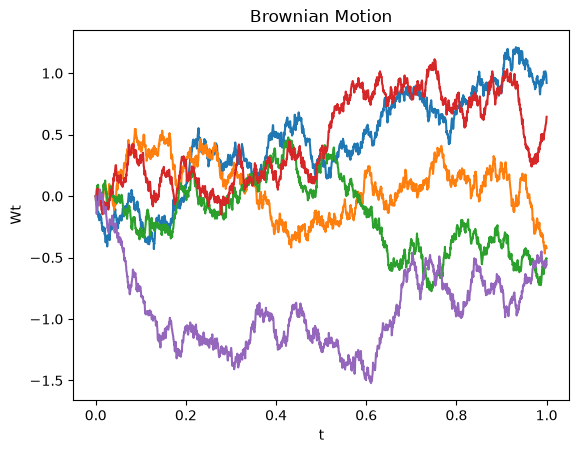

In [62]:
simulate_bm_plot(1, 2000, n_paths=5)

In [64]:
T=1
sigma=2
dt=0.005
q=0
gamma=0.1
k=1.5
A=140

In [78]:
#Let's try to calculate the benchmark strategy ? 

def simule_PNL_benchmark(T,dt,sigma,q,gamma,k,A):
    n=int(T/dt)
    t=np.linspace(0,T,n+1)
    spread=gamma*(sigma**2)*(T-t)+(2/gamma)*np.log(1+(gamma/k))

    mid_price=simulate_bm(T, n, 1)[0]
    
    lower=mid_price-spread/2
    upper=mid_price+spread/2


    plt.plot(t,mid_price)
    plt.fill_between(t,lower,upper,color='orange',alpha=0.2,label="spread")
    plt.xlabel("t")
    plt.title("Mid_price evolution with spread")


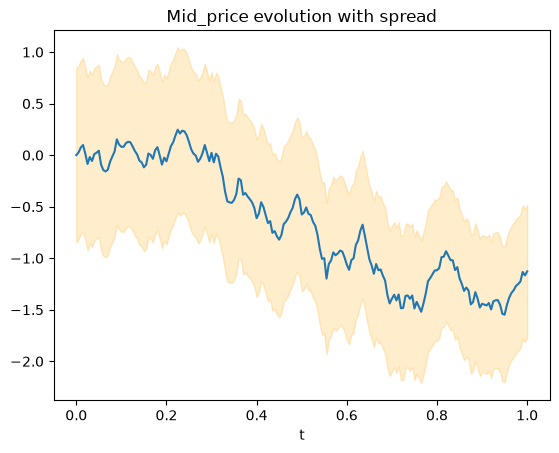

In [88]:
simule_PNL_benchmark(T,dt,sigma,q,gamma,k,A)